### `6.) RISK PRICING`

### Risk-Based Pricing Simulation

Lenders price loans based on the credit risk associated with each borrower. 

In lending portfolios, interest rates must compensate lenders for expected credit losses.


Interest income generated from loans must compensate lenders for expected credit losses.

Expected Profit = Interest Income − Expected Loss

This notebook evaluates whether the lending portfolio generates sufficient interest income to offset expected credit losses and examines how profitability varies across borrower risk segments.

This analysis helps determine whether loans are appropriately priced relative to their underlying credit risk.

LOAD PORTFOLIO RISK RESULTS

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

test = pd.read_parquet("portfolio_risk_results.parquet")

test.shape

(518706, 83)

This dataset alraedy contains : PD, LGD, EAD, Expected_loss, Actual_loss and grade

#### Extract Loan Term

Loan term is needed to estimate total interest income

In [5]:
test["term_years"] = test["term"] / 12

#### Estimate Interest Income

A simple approximation of interest income over the loan term

In [6]:
test["interest_income"] = test["loan_amnt"] * (test["int_rate"] / 100) * test["term_years"]

This assumes interest accrues across the loan term

#### Expected Profit

In [7]:
test["expected_profit"] = test["interest_income"] - test["expected_loss"]

#### Portfolio Profit Summary

In [9]:
portfolio_summary = pd.DataFrame({
    "Metric": [
        "Total Interest Income",
        "Total Expected Loss",
        "Total Expected Profit"
    ],
    "Amount (USD)": [
        test["interest_income"].sum(),
        test["expected_loss"].sum(),
        test["expected_profit"].sum()
    ]
})

# Format numbers with commas and no decimals
portfolio_summary["Amount (USD)"] = portfolio_summary["Amount (USD)"].apply(
    lambda x: f"${x:,.0f}"
)

portfolio_summary

,Metric,Amount (USD)
0,Total Interest Income,"$3,958,551,865"
1,Total Expected Loss,"$1,330,624,059"
2,Total Expected Profit,"$2,627,927,806"


### Portfolio Profitability

Portfolio profitability depends on whether interest income generated by the loan portfolio exceeds the expected credit losses.

Total interest income represents the estimated revenue generated from loan interest payments across the portfolio.

Expected Loss reflects the estimated credit losses derived from the PD–LGD–EAD framework.

If interest income is significantly higher than expected losses, the lending portfolio is profitable from a risk-adjusted perspective.

##### Risk Pricing Insights

Higher-risk loans typically carry higher interest rates in order to compensate lenders for the increased probability of default and potential credit losses.

However, not all high-interest loans are profitable. Some loans with very high expected losses may still generate negative expected profit despite elevated interest rates.

This analysis demonstrates how risk-based pricing attempts to balance credit risk and profitability across different borrower segments.

EXPECTED PROFIT DISTRIBUTION PLOT

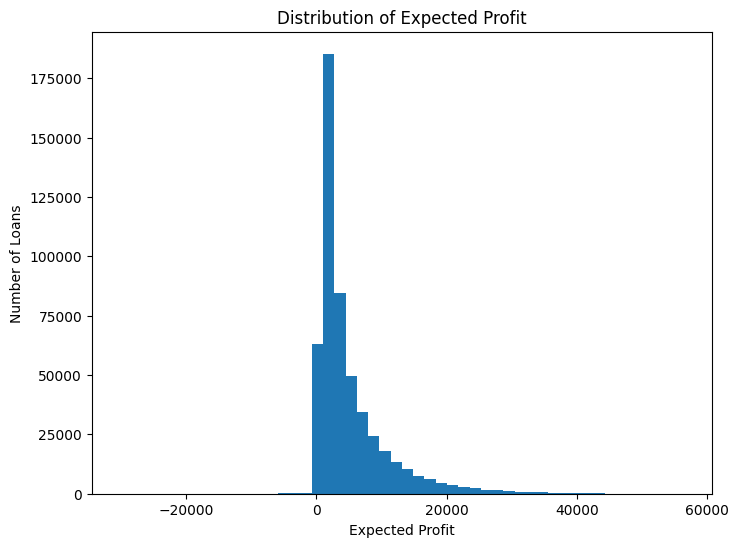

In [10]:
plt.figure(figsize=(8,6))

plt.hist(test["expected_profit"], bins=50)

plt.xlabel("Expected Profit")
plt.ylabel("Number of Loans")
plt.title("Distribution of Expected Profit")

plt.show()

The distribution of expected profit across loans is right-skewed, indicating that most loans generate moderate positive profit while a smaller number of loans contribute disproportionately larger profits.

A small number of loans exhibit negative expected profit, reflecting cases where expected credit losses exceed estimated interest income. These loans represent higher-risk segments where pricing may not fully compensate for underlying credit risk.

PROFIT BY CREDIT GRADE

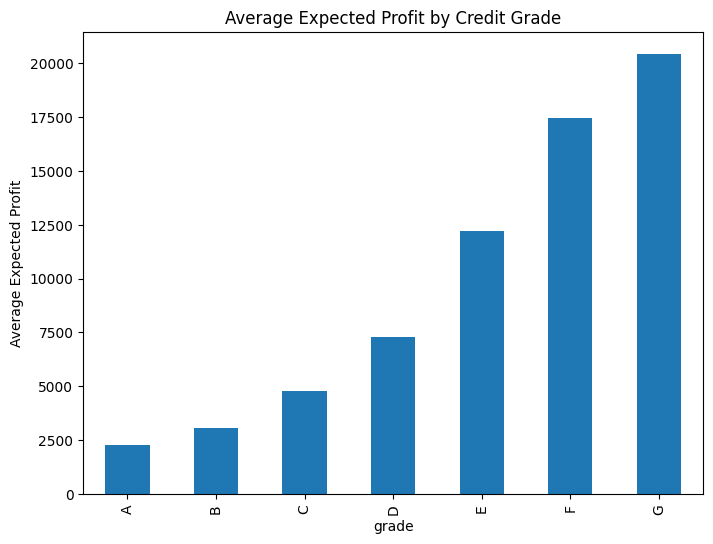

In [12]:
profit_by_grade = test.groupby("grade")["expected_profit"].mean()

profit_by_grade.plot(kind="bar", figsize=(8,6))

plt.ylabel("Average Expected Profit")
plt.title("Average Expected Profit by Credit Grade")

plt.show()

Average expected profit increases steadily from Grade A to Grade G. 

This pattern reflects the principle of risk-based pricing: borrowers with lower credit quality are charged higher interest rates to compensate lenders for the higher probability of default and loss severity.

Despite higher risk, the increased interest rates on lower-grade loans can generate higher expected profits, demonstrating how lenders balance credit risk and profitability across borrower segments.

#### Interest Rate vs Expected Profit

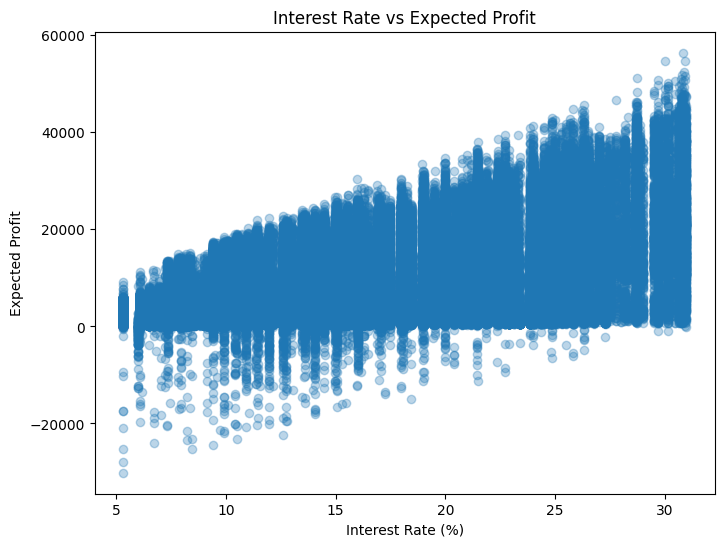

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(test["int_rate"], test["expected_profit"], alpha=0.3)

plt.xlabel("Interest Rate (%)")
plt.ylabel("Expected Profit")
plt.title("Interest Rate vs Expected Profit")

plt.show()

The relationship between interest rates and expected profit illustrates the impact of risk-based pricing.

Higher interest rates generally correspond to higher expected profits, as lenders charge higher rates to offset increased credit risk. However, the presence of some negative expected profit observations indicates that certain loans may still be underpriced relative to their underlying risk. 

This highlights the importance of accurate credit risk modelling and pricing calibration.